# Getting Started

The typical use case of `gpmap-tools` is the analysis of complete combinatorial genotype-phenotype maps, where the goal is to estimate the vector `f` encoding the phenotype for every possible genotype of a certain length. `gpmap-tools` leverages Gaussian process models to compute the posterior distribution over all possible `f`, enabling rigorous uncertainty quantification of phenotypic predictions and mutational effects across different genetic backgrounds. Additionally, `gpmap-tools` implements methods for visualizing high-dimensional genotype-phenotype maps to understand their main qualitative features. 

## Data

`gpmap-tools` can utilize two types of data for the inference of complete genotype-phenotype maps:

- **Multiplex Assays of Variant Effects (MAVE) data**: Experimental measurements of the phenotype `y` for a subset `X` of all possible sequences, possibly with known variance `y_var`.
- **Observations of natural sequences**: A collection of biological sequences `X` of a certain length, e.g., 5' splice site sequences in the human genome, where the probability of each possible sequence is considered the phenotype.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import gpmap.plot.mpl as mplot

from gpmap.space import SequenceSpace
from gpmap.randwalk import WMWalk
from gpmap.datasets import DataSet
from gpmap.inference import VCregression

Here, we will use experimental data from [GB1 protein binding to its target](https://doi.org/10.7554/eLife.16965), provided as a `DataSet` in `gpmap-tools`, to illustrate the inference and visualization of genotype-phenotype maps.  

In [2]:
data = DataSet('gb1').data
X, y, y_var = data.index.values, data.y.values, data.y_var.values
data

,y,y_var
sequence,,
AAAA,0.460831,0.046009
AAAG,-2.192261,0.255906
AAAH,-4.728306,2.064530
AAAI,-4.338842,2.095252
AAAL,-2.326240,0.087518
...,...,...
YYYS,-5.269987,0.291090
YYYT,-3.821426,0.074489
YYYV,-3.143536,0.074682


## Inference of genotype-phenotype maps

`gpmap-tools` provides a series of models to infer genotype-phenotype maps from different types of data in the `gpmap.inference` module. Here, we will use `VCregression`.

In [3]:
model = VCregression(seq_length=4, alphabet_type='protein')

We first infer the model hyperparamenters, in this case the variance explained by interactions of every possible order, as follows:

In [4]:
model.fit(X, y, y_var)

Once the hyperparameters defining the prior distribution are inferred, we can compute the posterior mean for the complete genotype-phenotype map `f`

In [5]:
result = model.predict()
result

,f
AAAA,0.117892
AAAC,-3.018971
AAAD,-3.230436
AAAE,-4.805853
AAAF,-3.357901
...,...
YYYS,-4.927780
YYYT,-3.674239
YYYV,-3.152652
YYYW,-4.663254


## Statistical analysis of genotype-phenotype maps

We can also evaluate the posterior mean and variance for a subset of sequences of interest, whether measured or not, and have an estimation of the uncertainty of the predictions for that particular sequence.

In [6]:
model.predict(X_pred=['VWGA'], calc_variance=True)

100%|██████████| 1/1 [00:04<00:00,  4.69s/it]


,f,f_var,f_std,ci_95_lower,ci_95_upper
VWGA,0.450483,0.001898,0.043569,0.363345,0.537621


Likewise, we can compute the posterior for specific sequence features such as mutational effects in specific genetic backgrounds by defining a `contrast_matrix` specifying the contrasts between sets of genotypes e.g. the effect of a `G3A` mutation in the `VWGA` sequence.

In [7]:
contrast_matrix = pd.DataFrame({"G3A": {"VWGA": -1, "VWAA": 1}})
contrast_matrix

,G3A
VWAA,1
VWGA,-1


In [8]:
model.make_contrasts(contrast_matrix)

100%|██████████| 2/2 [00:44<00:00, 22.44s/it]


,estimate,std,ci_95_lower,ci_95_upper,p(|x|>0)
G3A,1.110173,0.059788,0.990597,1.22975,1.0


##  Visualizing the inferred genotype-phenotype map

Once we have an estimate of the genotype-phenotype map `f` given by the posterior mean, we can generate a low dimensional representation to understand what are their main qualitative features.

We first compute the coordinates of the low-dimensional representation stored as a `pd.DataFrame`, so it can be easily stored and read from a file

In [9]:
space = SequenceSpace(X=result.index.values, y=result.f.values)
rw = WMWalk(space)
rw.calc_visualization(mean_function=0)
nodes_df, edges_df = rw.nodes_df, rw.space.get_edges_df()
nodes_df

,1,2,3,4,5,6,7,8,9,10,function,stationary_freq
AAAA,-0.265346,-1.142056,-0.028284,-0.146887,-0.590068,0.286066,-0.110796,-0.179020,-0.469251,-0.022557,0.117892,9.610648e-05
AAAC,0.021210,-0.317150,0.007629,-0.127876,-0.455667,0.212128,0.002862,0.170135,0.640595,-0.054920,-3.018971,3.809275e-06
AAAD,-0.039432,-0.210704,0.051189,-0.128539,-0.229740,0.226953,0.026423,0.280779,0.507739,0.376972,-3.230436,3.064331e-06
AAAE,-0.019125,-0.216818,0.125636,-0.137143,-0.241918,0.212173,0.013606,0.198738,0.377012,0.275633,-4.805853,6.057012e-07
AAAF,0.135107,-0.234207,0.025914,-0.177627,-0.313035,0.211957,0.004641,0.142758,0.313033,0.191767,-3.357901,2.687632e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
YYYS,0.085554,-0.009269,0.019560,-0.079093,-0.130788,0.108081,0.006011,0.108595,0.328963,0.176611,-4.927780,5.342784e-07
YYYT,-0.096581,0.157110,0.011680,0.291572,-0.160266,0.092541,-0.055400,0.088160,0.218631,0.651619,-3.674239,1.940857e-06
YYYV,0.000852,0.158549,0.017363,0.111156,0.151607,0.264393,-0.193680,0.156199,0.236435,-0.015429,-3.152652,3.319698e-06
YYYW,0.163296,0.092562,0.035020,-0.059211,0.024689,0.068828,0.025022,0.136109,0.240455,0.208723,-4.663254,7.014363e-07


Using the generated `DataFrame`, we can now visualize the inferred genotype-phenotype map and explore its structure

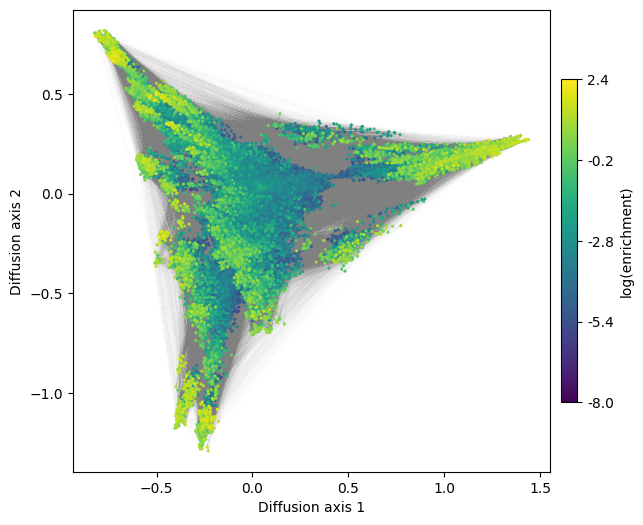

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(7, 6))
mplot.plot_visualization(axes,
                         nodes_df,
                         edges_df=edges_df,
                         nodes_size=5,
                         nodes_cmap_label='log(enrichment)',
                         edges_alpha=0.005)

See the specific sections of the documentation for more details and examples of how to explore these interesting high dimensional objects